## T검정

#### - 일반 t검정
: 두 집단의 분산이 같음을 가정

t-statistic: 2.095849486142243
p-value: 0.05049920424919774


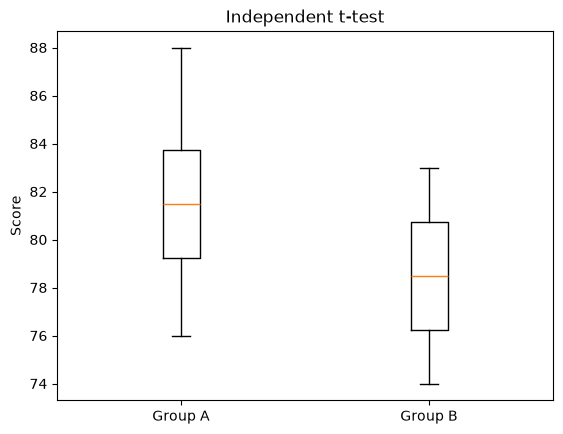

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

group_a = np.array([78, 82, 85, 80, 76, 88, 84, 81, 79, 83])
group_b = np.array([75, 79, 81, 77, 74, 83, 80, 78, 76, 82])

# 일반 t검정: 등분산 가정
stat, p_value = ttest_ind(group_a, group_b, equal_var=True)

print("t-statistic:", stat)
print("p-value:", p_value)

# 시각화
plt.boxplot([group_a, group_b], tick_labels=["Group A", "Group B"])
plt.ylabel("Score")
plt.title("Independent t-test")
plt.show()

#### - 웰치의 t검정
: 두 독립 집단의 평균 차이를 검정할 때, 두 집단의 분산이 같지 않거나 표본 크기가 다를 때 주로 쓰는 방법 

t-statistic: 1.3452275349402583
p-value: 0.2064717499648904


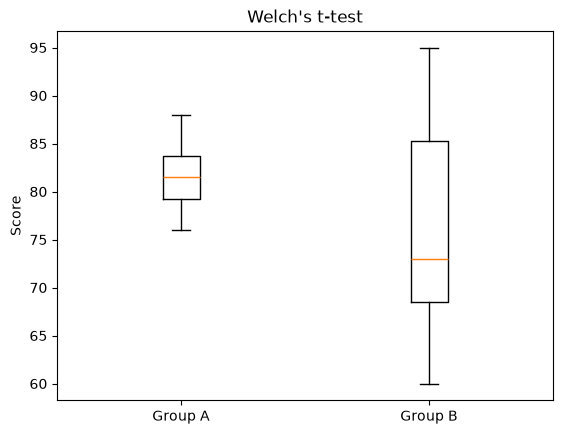

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

group_a = np.array([78, 82, 85, 80, 76, 88, 84, 81, 79, 83])
group_b = np.array([60, 72, 91, 68, 86, 74, 95, 65, 83, 70])

# Welch t검정: 등분산 가정하지 않음
stat, p_value = ttest_ind(group_a, group_b, equal_var=False)

print("t-statistic:", stat)
print("p-value:", p_value)

# 시각화
plt.boxplot([group_a, group_b], tick_labels=["Group A", "Group B"])
plt.ylabel("Score")
plt.title("Welch's t-test")
plt.show()

## 정규성

#### - Q-Q플롯: 데이터의 실제 분위수와 정규분포의 이론적 분위수를 비교하는 그래프입니다.

점들이 대각선에 대체로 붙어 있음 → 정규분포에 가까움
점들이 휘어지거나 양 끝에서 크게 벗어남 → 치우침, 두꺼운 꼬리, 이상치 등의 가능성

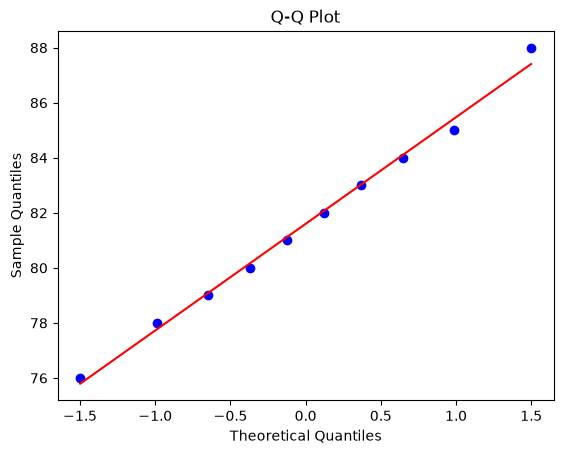

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

data = np.array([78, 82, 85, 80, 76, 88, 84, 81, 79, 83])

stats.probplot(data, dist="norm", plot=plt)

plt.title("Q-Q Plot")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.show()

Q-Q 플롯은 숫자 하나로 결론을 내리기보다는 분포가 어느 부분에서 정규분포와 다른지 시각적으로 확인하는 데 유용합니다.

#### - 샤피로 월크 검정: 데이터가 정규분포를 따르는지 검정합니다.

귀무가설 H0 : 데이터는 정규분포를 따른다.

대립가설 H1 : 데이터는 정규분포를 따르지 않는다.

검정통계량: 0.9947299182559034
p-value: 0.999762699356853
정규성을 위반했다고 보기 어려움


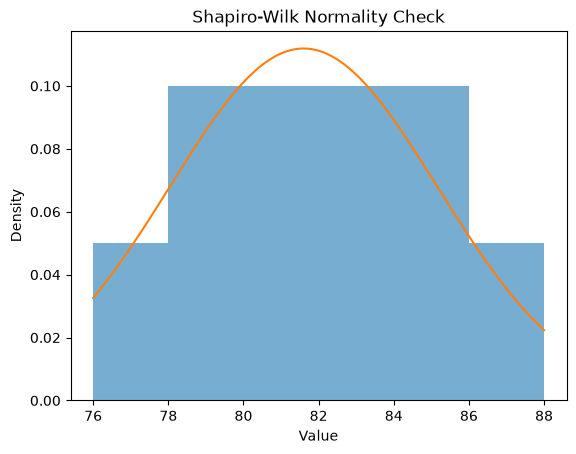

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro, norm

data = np.array([78, 82, 85, 80, 76, 88, 84, 81, 79, 83])

stat, p_value = shapiro(data)

print("검정통계량:", stat)
print("p-value:", p_value)

if p_value >= 0.05:
    print("정규성을 위반했다고 보기 어려움")
else:
    print("정규분포와 유의하게 다름")

# 히스토그램 + 정규분포 곡선
plt.hist(data, bins=6, density=True, alpha=0.6)

x = np.linspace(data.min(), data.max(), 100)
y = norm.pdf(x, np.mean(data), np.std(data, ddof=1))

plt.plot(x, y)
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Shapiro-Wilk Normality Check")
plt.show()

샤피로-윌크 검정은 정규성 검정에서 많이 사용되지만, 표본이 매우 크면 사소한 차이도 유의하게 나올 수 있습니다. 따라서 Q-Q 플롯과 함께 확인하는 것이 좋습니다.

#### - 콜모고로프-스미르노프 검정: 표본의 누적분포가 특정 이론적 분포의 누적분포와 얼마나 다른지를 비교합니다.

귀무가설 H0 : 데이터가 지정된 분포를 따른다.

대립가설 H1 : 지정된 분포를 따르지 않는다.

검정통계량: 0.073202852093399
p-value: 0.9999998319352221


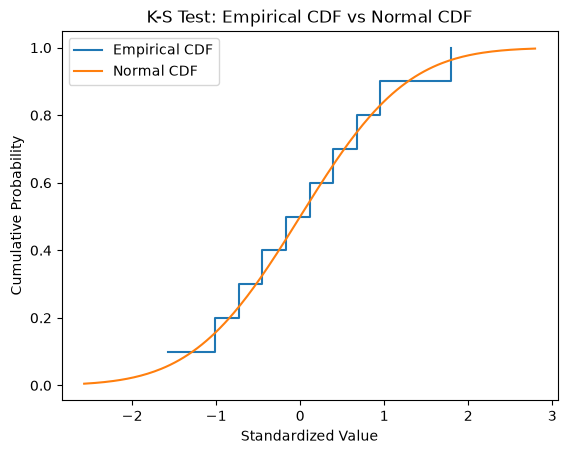

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest, norm

data = np.array([78, 82, 85, 80, 76, 88, 84, 81, 79, 83])

# 표준화
standardized_data = (
    data - np.mean(data)
) / np.std(data, ddof=1)

stat, p_value = kstest(standardized_data, "norm")

print("검정통계량:", stat)
print("p-value:", p_value)

# 경험적 누적분포
sorted_data = np.sort(standardized_data)
ecdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

# 이론적 정규분포 누적분포
x = np.linspace(sorted_data.min() - 1, sorted_data.max() + 1, 200)

plt.step(sorted_data, ecdf, where="post", label="Empirical CDF")
plt.plot(x, norm.cdf(x), label="Normal CDF")

plt.xlabel("Standardized Value")
plt.ylabel("Cumulative Probability")
plt.title("K-S Test: Empirical CDF vs Normal CDF")
plt.legend()
plt.show()

다만 K-S 검정은 원래 비교할 정규분포의 평균과 표준편차를 사전에 알고 있다는 전제가 있습니다. 같은 데이터에서 평균과 표준편차를 추정했다면 일반 K-S 검정의 p-value가 정확하지 않을 수 있으므로, 기초 분석에서는 보통 샤피로-윌크 검정과 Q-Q 플롯이 더 편리합니다.

## 등분산성

#### - 바틀렛 검정: 여러 집단의 분산이 같은지 검정합니다.

귀무가설 H0 : 모든 집단의 분산이 같다.

대립가설 H1 : 적어도 한 집단의 분산이 다르다.

Group A 분산: 12.711111111111112
Group B 분산: 136.7111111111111
검정통계량: 9.949452753170464
p-value: 0.0016089722007035356
집단 간 분산이 유의하게 다름


c:\Utility\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51665 (\N{HANGUL SYLLABLE JIB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Utility\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Utility\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Utility\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Utility\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Ut

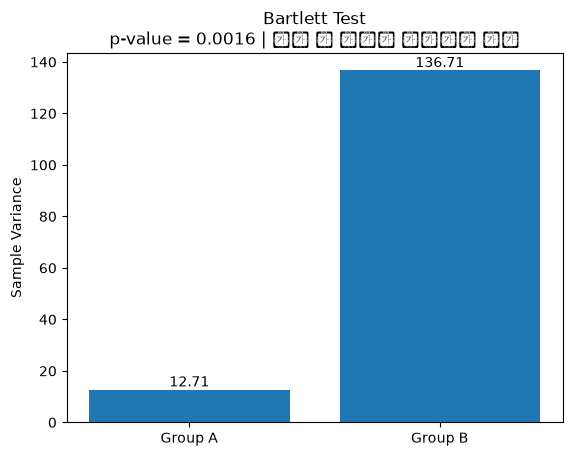

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bartlett

group_a = np.array(
    [78, 82, 85, 80, 76, 88, 84, 81, 79, 83],
    dtype=float
)

group_b = np.array(
    [60, 72, 91, 68, 86, 74, 95, 65, 83, 70],
    dtype=float
)

# Bartlett 검정
stat, p_value = bartlett(group_a, group_b)

# 각 집단의 표본분산
var_a = np.var(group_a, ddof=1)
var_b = np.var(group_b, ddof=1)

print("Group A 분산:", var_a)
print("Group B 분산:", var_b)
print("검정통계량:", stat)
print("p-value:", p_value)

if p_value >= 0.05:
    result = "등분산 가정을 기각하지 못함"
else:
    result = "집단 간 분산이 유의하게 다름"

print(result)

# 시각화
groups = ["Group A", "Group B"]
variances = [var_a, var_b]

bars = plt.bar(groups, variances)

# 막대 위에 실제 분산 표시
for bar, value in zip(bars, variances):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.ylabel("Sample Variance")
plt.title(
    f"Bartlett Test\n"
    f"p-value = {p_value:.4f} | {result}"
)

plt.show()

해석:

- p-value >= 0.05 → 등분산 가정을 기각하지 못함
- p-value < 0.05 → 집단 간 분산이 다르다고 판단

바틀렛 검정은 데이터가 정규분포를 따른다는 가정에 민감합니다. 데이터가 정규분포에서 벗어나거나 이상치가 있으면 실제보다 등분산성이 위반된 것처럼 나올 수 있습니다.

#### - 레빈 검정: 레빈 검정도 집단 간 분산이 같은지 확인합니다.

귀무가설 H0 : 모든 집단의 분산이 같다.

대립가설 H1 : 적어도 한 집단의 분산이 다르다.

Group A 중앙값: 81.5
Group B 중앙값: 73.0
Group A 평균 절대편차: 2.8
Group B 평균 절대편차: 9.4
검정통계량: 7.864393179538616
p-value: 0.011726818304612885
집단 간 분산이 유의하게 다름


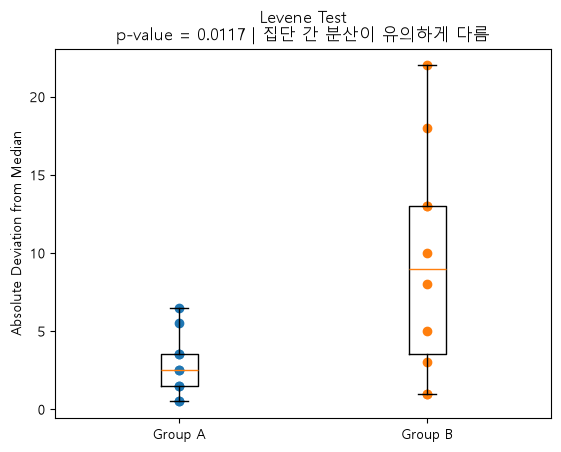

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import levene

group_a = np.array(
    [78, 82, 85, 80, 76, 88, 84, 81, 79, 83],
    dtype=float
)

group_b = np.array(
    [60, 72, 91, 68, 86, 74, 95, 65, 83, 70],
    dtype=float
)

# Levene 검정
stat, p_value = levene(
    group_a,
    group_b,
    center="median"
)

# 각 집단 중앙값
median_a = np.median(group_a)
median_b = np.median(group_b)

# 중앙값으로부터의 절대편차
dev_a = np.abs(group_a - median_a)
dev_b = np.abs(group_b - median_b)

print("Group A 중앙값:", median_a)
print("Group B 중앙값:", median_b)

print("Group A 평균 절대편차:", np.mean(dev_a))
print("Group B 평균 절대편차:", np.mean(dev_b))

print("검정통계량:", stat)
print("p-value:", p_value)

if p_value >= 0.05:
    result = "등분산 가정을 기각하지 못함"
else:
    result = "집단 간 분산이 유의하게 다름"

print(result)

# 시각화
plt.boxplot(
    [dev_a, dev_b],
    tick_labels=["Group A", "Group B"]
)

# 실제 데이터 점 추가
plt.scatter(
    np.ones(len(dev_a)),
    dev_a
)

plt.scatter(
    np.ones(len(dev_b)) * 2,
    dev_b
)

plt.ylabel("Absolute Deviation from Median")

plt.title(
    f"Levene Test\n"
    f"p-value = {p_value:.4f} | {result}"
)

plt.show()

레빈 검정은 바틀렛 검정보다 정규성 위반과 이상치에 비교적 강합니다. 특히 다음처럼 중앙값을 기준으로 계산하는 방식이 많이 사용됩니다.

## 비모수 버전의 2개 독립표본 비교

#### - 윌콕슨 순위합 검정(Wilcoxon Rank Sum Test)

: 두 독립집단의 데이터를 하나로 합친 뒤 실제 값 자체가 아니라 순위(rank)를 이용하여 두 집단이 서로 다른 위치에 있는지를 검정합니다.

귀무가설 H0 : 두 집단은 같은 분포에서 추출되었다.

대립가설 H1 : 한 집단의 값이 다른 집단보다 전반적으로 크거나 작은 경향이 있다.

검정통계량: 1.096096971726759
p-value: 0.27303633975118835
두 집단의 차이가 유의하지 않음


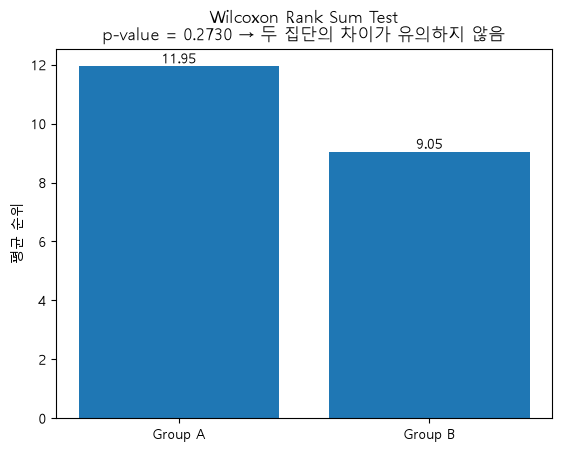

In [19]:
from scipy.stats import ranksums, rankdata

# Wilcoxon Rank Sum Test
stat, p_value = ranksums(
    group_a,
    group_b,
    alternative="two-sided"
)

print("검정통계량:", stat)
print("p-value:", p_value)

if p_value >= 0.05:
    result = "두 집단의 차이가 유의하지 않음"
else:
    result = "두 집단의 차이가 유의함"

print(result)

# ---------------------------------
# 시각화: 실제 값 대신 '순위' 비교
# ---------------------------------

combined = np.concatenate([group_a, group_b])
ranks = rankdata(combined)

rank_a = ranks[:len(group_a)]
rank_b = ranks[len(group_a):]

mean_rank_a = np.mean(rank_a)
mean_rank_b = np.mean(rank_b)

bars = plt.bar(
    ["Group A", "Group B"],
    [mean_rank_a, mean_rank_b]
)

for bar, value in zip(
    bars,
    [mean_rank_a, mean_rank_b]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.ylabel("평균 순위")
plt.title(
    f"Wilcoxon Rank Sum Test\n"
    f"p-value = {p_value:.4f} → {result}"
)

plt.show()

해석:

- p-value >= 0.05 → 두 집단의 차이가 있다고 보기 어려움.
- p-value < 0.05 → 두 집단의 순위 분포에 유의한 차이가 있음.

주의할 점은 scipy.stats.ranksums()는 두 집단 사이에 동일한 값, 즉 동순위(tie)가 있는 데이터를 적절히 처리하지 않습니다. 실제 데이터에 동일값이 있다면 아래의 Mann–Whitney U 검정을 사용하는 편이 낫습니다.

#### - 맨–휘트니 U 검정(Mann–Whitney U Test)

: 두 독립집단의 값들을 서로 비교하여, 한 집단의 값이 다른 집단의 값보다 전반적으로 더 큰지 또는 작은지를 순위에 기반해 검정합니다.

귀무가설 H0 : 두 집단의 분포가 같다.

대립가설 H1 : 두 집단의 분포가 다르다.

U 통계량: 64.5
p-value: 0.28973706282213785
두 집단의 차이가 유의하지 않음
A가 B보다 큰 경향의 상대적 비율: 0.645


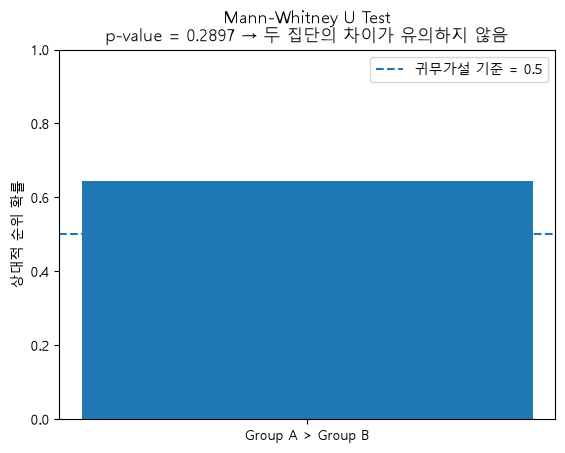

In [20]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(
    group_a,
    group_b,
    alternative="two-sided",
    method="auto"
)

print("U 통계량:", stat)
print("p-value:", p_value)

if p_value >= 0.05:
    result = "두 집단의 차이가 유의하지 않음"
else:
    result = "두 집단의 차이가 유의함"

print(result)

# ---------------------------------
# 시각화: U를 비교확률 형태로 변환
# ---------------------------------

probability = stat / (
    len(group_a) * len(group_b)
)

print(
    "A가 B보다 큰 경향의 상대적 비율:",
    probability
)

plt.bar(
    ["Group A > Group B"],
    [probability]
)

# 귀무가설 기준
plt.axhline(
    0.5,
    linestyle="--",
    label="귀무가설 기준 = 0.5"
)

plt.ylim(0, 1)
plt.ylabel("상대적 순위 확률")

plt.title(
    f"Mann-Whitney U Test\n"
    f"p-value = {p_value:.4f} → {result}"
)

plt.legend()
plt.show()

해석:

- p-value >= 0.05 → 두 집단의 분포 차이가 유의하지 않음.
- p-value < 0.05 → 두 집단의 분포 차이가 유의함.

그래프의 0.5가 두 집단 사이에 우세한 쪽이 없는 기준입니다. U/(n₁×n₂)는 한 집단의 관측값이 다른 집단보다 큰 상대적 경향을 직관적으로 볼 수 있게 해줍니다. Mann–Whitney U의 U 통계량은 이와 같은 쌍별 순위 비교에 기반합니다.

다만 Mann–Whitney U를 무조건 "두 중앙값이 같은가?"라는 검정으로 해석하면 안 됩니다. 두 집단의 분포 형태가 비슷한 경우에는 위치 차이로 해석하기 쉽지만, 분산이나 분포 형태가 크게 다르면 더 일반적으로 분포 또는 확률적 순서의 차이를 검정한다고 이해하는 것이 안전합니다.

#### 플리그너–폴리셀로 검정(Fligner–Policello Test)

: Mann–Whitney U와 비슷한 순위 기반 검정이지만, 두 집단의 분산이나 분포의 퍼짐이 서로 달라도 사용할 수 있도록 고안된 방법입니다.

특히 두 분포가 각각 대칭적이라는 가정하에서는 두 집단의 위치 또는 중앙값 차이를 비교할 수 있습니다. Mann–Whitney–Wilcoxon과 달리 두 집단의 분포 형태가 동일할 필요는 없지만, 각 분포의 대칭성은 요구됩니다.

귀무가설 H0 : 두 집단의 중앙 위치가 같다.

대립가설 H1 : 두 집단의 중앙 위치가 다르다.

검정통계량: -0.9680713893445878
p-value: 0.3330087175052976
두 집단의 위치 차이가 유의하지 않음


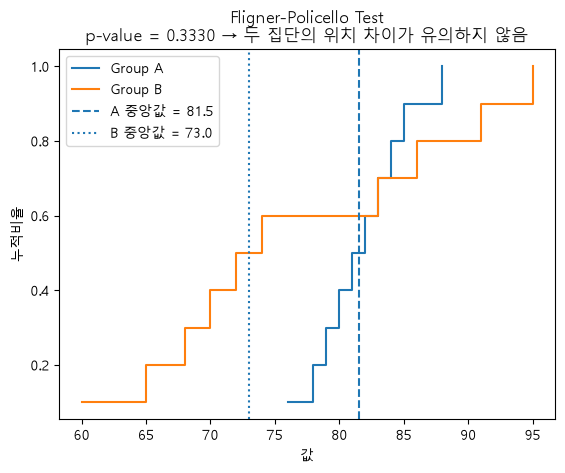

In [22]:
from scipy.stats import norm

def fligner_policello(x, y):

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # 각 관측값의 placement score
    px = np.array([
        np.sum(y < value)
        + 0.5 * np.sum(y == value)
        for value in x
    ])

    py = np.array([
        np.sum(x < value)
        + 0.5 * np.sum(x == value)
        for value in y
    ])

    sx = np.sum(px)
    sy = np.sum(py)

    mx = np.mean(px)
    my = np.mean(py)

    vx = np.sum((px - mx) ** 2)
    vy = np.sum((py - my) ** 2)

    z = (
        (sy - sx)
        /
        (2 * np.sqrt(vx + vy + mx * my))
    )

    p_value = 2 * norm.sf(abs(z))

    return z, p_value


stat, p_value = fligner_policello(
    group_a,
    group_b
)

print("검정통계량:", stat)
print("p-value:", p_value)

if p_value >= 0.05:
    result = "두 집단의 위치 차이가 유의하지 않음"
else:
    result = "두 집단의 위치 차이가 유의함"

print(result)

# ---------------------------------
# 시각화: ECDF + 중앙값
# ---------------------------------

a_sorted = np.sort(group_a)
b_sorted = np.sort(group_b)

a_ecdf = (
    np.arange(1, len(group_a) + 1)
    / len(group_a)
)

b_ecdf = (
    np.arange(1, len(group_b) + 1)
    / len(group_b)
)

plt.step(
    a_sorted,
    a_ecdf,
    where="post",
    label="Group A"
)

plt.step(
    b_sorted,
    b_ecdf,
    where="post",
    label="Group B"
)

plt.axvline(
    np.median(group_a),
    linestyle="--",
    label=f"A 중앙값 = {np.median(group_a):.1f}"
)

plt.axvline(
    np.median(group_b),
    linestyle=":",
    label=f"B 중앙값 = {np.median(group_b):.1f}"
)

plt.xlabel("값")
plt.ylabel("누적비율")

plt.title(
    f"Fligner-Policello Test\n"
    f"p-value = {p_value:.4f} → {result}"
)

plt.legend()
plt.show()

해석:

- p-value >= 0.05 → 두 집단의 중앙 위치 차이가 유의하지 않음
- p-value < 0.05 → 두 집단의 중앙 위치가 유의하게 다름

이 검정에서는 단순 boxplot보다는 ECDF를 같이 그리는 것이 유용합니다. 두 집단의 중앙값 위치뿐 아니라 분포의 퍼짐 자체가 서로 다른 상황도 같이 볼 수 있기 때문입니다.

Fligner–Policello는 분산이 같지 않아도 사용할 수 있다는 장점이 있지만, 두 집단의 분포가 각각 대칭적이어야 한다는 조건이 있습니다.

#### 브루너–문첼 검정(Brunner–Munzel Test)

: 두 독립집단의 분포가 다르고 분산도 서로 다를 수 있는 상황에서, 한 집단의 관측값이 다른 집단보다 클 확률이 50%와 다른지를 검정하는 비모수 방법입니다.

Mann–Whitney U와 달리 두 집단의 분포가 동일한 형태라는 조건을 요구하지 않습니다. SciPy에서도 공식적으로 제공됩니다.

귀무가설 H0 : 두 집단에서 무작위로 하나씩 뽑았을 때 어느 집단의 값이 더 클 가능성도 동일하다.

대립가설 H1 : 한 집단의 값이 다른 집단보다 더 클 가능성이 다르다.

W 통계량: -0.9691826280391768
p-value: 0.356765840770596
두 집단의 상대적 위치 차이가 유의하지 않음
상대효과: 0.645


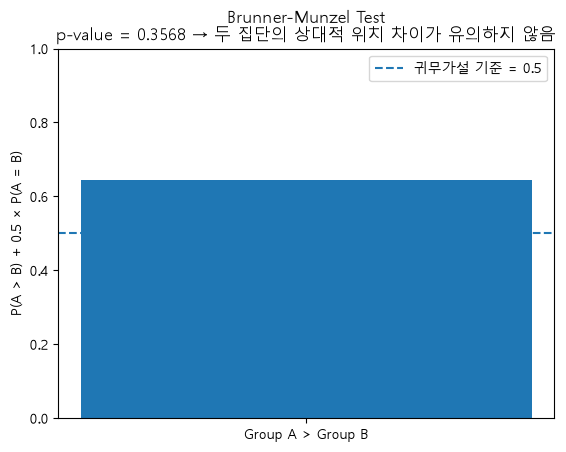

In [23]:
from scipy.stats import brunnermunzel

stat, p_value = brunnermunzel(
    group_a,
    group_b,
    alternative="two-sided",
    distribution="t"
)

print("W 통계량:", stat)
print("p-value:", p_value)

if p_value >= 0.05:
    result = "두 집단의 상대적 위치 차이가 유의하지 않음"
else:
    result = "두 집단의 상대적 위치 차이가 유의함"

print(result)

# ---------------------------------
# 상대효과 계산
# P(A > B) + 0.5 P(A = B)
# ---------------------------------

wins = 0

for a in group_a:
    for b in group_b:

        if a > b:
            wins += 1

        elif a == b:
            wins += 0.5

relative_effect = (
    wins
    /
    (len(group_a) * len(group_b))
)

print("상대효과:", relative_effect)

# 시각화
plt.bar(
    ["Group A > Group B"],
    [relative_effect]
)

plt.axhline(
    0.5,
    linestyle="--",
    label="귀무가설 기준 = 0.5"
)

plt.ylim(0, 1)

plt.ylabel(
    "P(A > B) + 0.5 × P(A = B)"
)

plt.title(
    f"Brunner-Munzel Test\n"
    f"p-value = {p_value:.4f} → {result}"
)

plt.legend()
plt.show()

해석:

- p-value >= 0.05 → 두 집단 사이의 확률적 우위가 유의하지 않음
- p-value < 0.05 → 한 집단이 다른 집단보다 큰 값을 가질 경향이 유의하게 다름

여기서 그래프의 핵심은 0.5입니다.

상대효과 = 0.5
→ 어느 집단이 더 큰 값을 가질 가능성도 동일
상대효과 > 0.5
→ Group A가 Group B보다 큰 값일 가능성이 높음
상대효과 < 0.5
→ Group B가 Group A보다 큰 값일 가능성이 높음

Brunner–Munzel은 바로 이러한 확률적 동등성(stochastic equality)을 검정하며, Wilcoxon–Mann–Whitney와 달리 두 모집단의 분포가 동일하다는 가정을 필요로 하지 않습니다. SciPy는 기본적으로 distribution="t"를 제공하며, 원 논문 저자들은 표본 크기가 50 이하인 경우 t 분포 근사를 권장하고 있습니다.

In [24]:
%pip install -U scikit-posthocs

Note: you may need to restart the kernel to use updated packages.


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

control = np.array(
    [12, 15, 14, 10, 13, 16, 11, 14, 13, 12],
    dtype=float
)

group_a = np.array(
    [13, 16, 15, 12, 14, 17, 14, 15, 13, 16],
    dtype=float
)

group_b = np.array(
    [22, 24, 19, 23, 25, 21, 20, 24, 22, 23],
    dtype=float
)

group_c = np.array(
    [8, 9, 11, 7, 10, 8, 12, 9, 7, 10],
    dtype=float
)

## 3집단 이상의 비모수검정

#### - 크러스컬-윌리스 검정(Kruskal-Wallis Test)

: 서로 독립적인 3개 이상의 집단을 비교하는 비모수 검정입니다.

일원분산분석(One-way ANOVA)의 비모수적 대안으로, 실제 관측값 대신 전체 데이터를 순위로 변환하여 집단 간 차이를 검정합니다. SciPy의 kruskal()은 2개 이상의 독립표본에 사용할 수 있으며, 검정이 유의하더라도 어느 집단끼리 다른지는 알려주지 않으므로 사후검정이 필요합니다.

귀무가설 H0 : 모든 집단의 분포 위치가 같다.

대립가설 H1 : 적어도 하나의 집단이 다른 집단과 다르다.

H 통계량: 32.75139949109414
p-value: 3.6339526952512065e-07
적어도 하나의 집단이 유의하게 다름


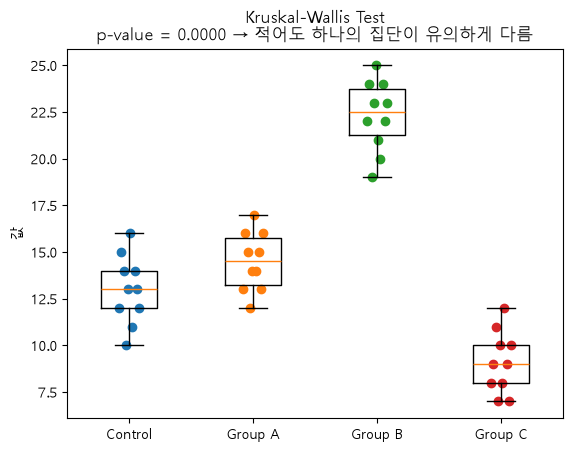

In [27]:
from scipy.stats import kruskal

# Kruskal-Wallis 검정
stat, p_value = kruskal(
    control,
    group_a,
    group_b,
    group_c
)

print("H 통계량:", stat)
print("p-value:", p_value)

if p_value >= 0.05:
    result = "집단 간 유의한 차이가 없음"
else:
    result = "적어도 하나의 집단이 유의하게 다름"

print(result)

# -----------------------------
# 시각화: Boxplot + 실제 관측값
# -----------------------------

groups = [
    control,
    group_a,
    group_b,
    group_c
]

labels = [
    "Control",
    "Group A",
    "Group B",
    "Group C"
]

plt.boxplot(
    groups,
    tick_labels=labels
)

# 실제 데이터 점 추가
for i, group in enumerate(groups, start=1):

    jitter = np.linspace(
        -0.08,
        0.08,
        len(group)
    )

    plt.scatter(
        np.full(len(group), i) + jitter,
        group
    )

plt.ylabel("값")

plt.title(
    f"Kruskal-Wallis Test\n"
    f"p-value = {p_value:.4f} → {result}"
)

plt.show()

해석:

- p-value >= 0.05 → 집단 간 유의한 차이가 있다고 보기 어려움
- p-value < 0.05 → 적어도 하나의 집단이 다른 집단과 유의하게 다름

Kruskal-Wallis 검정 결과만으로는

A와 B가 다른가?
A와 C가 다른가?
B와 C가 다른가?

를 알 수 없습니다.

따라서 유의한 결과가 나오면 Steel-Dwass, Dunn 등의 사후검정을 추가로 실시합니다.

시각화는 막대그래프보다 boxplot + 개별 관측값이 적합합니다. 비모수검정을 사용하는 이유인 분포 형태, 이상치, 중앙부 위치 등을 함께 볼 수 있기 때문입니다.

#### - 스틸-드와스 검정(Steel-Dwass Test)

: 3개 이상의 독립집단에서 모든 집단을 서로 1:1로 비교하는 비모수 다중비교 방법입니다.

예를 들어 집단이 4개라면

- Control vs A
- Control vs B
- Control vs C
- A vs B
- A vs C
- B vs C

처럼 가능한 모든 쌍을 비교합니다.

Python의 scikit-posthocs에서는 정확한 함수명이 posthoc_dscf()이며, Dwass-Steel-Critchlow-Fligner(DSCF) all-pairs 검정을 구현합니다. 이 방법은 각 집단 쌍마다 다시 순위를 계산하는 U-test 확장형이며, 비정규 자료의 모든 쌍 비교에 사용할 수 있습니다.

귀무가설 H0 : 비교하는 두 집단 사이에 차이가 없다.

대립가설 H1 : 비교하는 두 집단 사이에 차이가 있다.

In [28]:
import scikit_posthocs as sp

# DataFrame 생성
df = pd.DataFrame({
    "value": np.concatenate([
        control,
        group_a,
        group_b,
        group_c
    ]),
    "group": (
        ["Control"] * len(control)
        + ["Group A"] * len(group_a)
        + ["Group B"] * len(group_b)
        + ["Group C"] * len(group_c)
    )
})

# DSCF 검정
p_matrix = sp.posthoc_dscf(
    df,
    val_col="value",
    group_col="group"
)

print(p_matrix)

          Control   Group A   Group B   Group C
Control  1.000000  0.292852  0.000873  0.004015
Group A  0.292852  1.000000  0.000868  0.000997
Group B  0.000873  0.000868  1.000000  0.000868
Group C  0.004015  0.000997  0.000868  1.000000


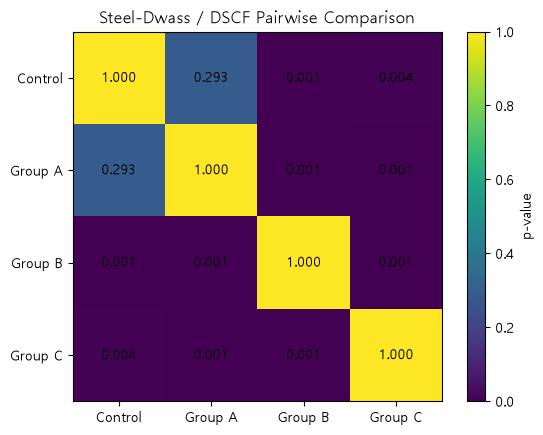

In [29]:
# p-value matrix
matrix = p_matrix.to_numpy(dtype=float)

fig, ax = plt.subplots()

image = ax.imshow(
    matrix,
    vmin=0,
    vmax=1
)

ax.set_xticks(
    range(len(p_matrix.columns)),
    labels=p_matrix.columns
)

ax.set_yticks(
    range(len(p_matrix.index)),
    labels=p_matrix.index
)

# 각 칸에 p-value 표시
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):

        value = matrix[i, j]

        if np.isfinite(value):
            ax.text(
                j,
                i,
                f"{value:.3f}",
                ha="center",
                va="center"
            )

plt.colorbar(
    image,
    label="p-value"
)

plt.title(
    "Steel-Dwass / DSCF Pairwise Comparison"
)

plt.show()

해석:

- p-value >= 0.05 → 해당 두 집단의 차이가 유의하지 않음
- p-value < 0.05 → 해당 두 집단의 차이가 유의함

즉, Kruskal-Wallis가

“네 집단 중 어디든 차이가 있는가?”

를 보는 검정이라면,

Steel-Dwass/DSCF는

“그래서 정확히 어느 집단과 어느 집단이 다른가?”

를 확인하는 사후 다중비교입니다. DSCF는 pairwise U-test의 확장으로 각 쌍을 다시 순위화하며, p-value는 Tukey 분포를 이용해 계산합니다.

#### - 스틸 검정(Steel Test)

: 하나의 대조군(Control)과 여러 처리군을 각각 비교하는 비모수 다중비교 방법입니다.

즉, 모든 집단끼리 비교하지 않습니다.

집단이 다음과 같다면

Control
Group A
Group B
Group C

Steel 검정에서는

Control vs Group A
Control vs Group B
Control vs Group C

만 비교합니다.

따라서 비모수 버전의 Dunnett 검정이라고 생각하면 이해하기 쉽습니다. scikit-posthocs 역시 Steel 검정을 여러 처리군을 하나의 대조군과 비교하는 Dunnett 검정의 비모수 대안으로 정의합니다.

귀무가설 H0 : 각 처리군은 대조군과 차이가 없다.

대립가설 H1 : 해당 처리군은 대조군과 차이가 있다.

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scikit_posthocs as sp

control = np.array(
    [12, 15, 14, 10, 13, 16, 11, 14, 13, 12],
    dtype=float
)

group_a = np.array(
    [13, 16, 15, 12, 14, 17, 14, 15, 13, 16],
    dtype=float
)

group_b = np.array(
    [22, 24, 19, 23, 25, 21, 20, 24, 22, 23],
    dtype=float
)

group_c = np.array(
    [8, 9, 11, 7, 10, 8, 12, 9, 7, 10],
    dtype=float
)

df = pd.DataFrame({
    "value": np.concatenate([
        control,
        group_a,
        group_b,
        group_c
    ]),
    "group": (
        ["Control"] * len(control)
        + ["Group A"] * len(group_a)
        + ["Group B"] * len(group_b)
        + ["Group C"] * len(group_c)
    )
})

# Dunn 사후검정 + Holm 보정
result = sp.posthoc_dunn(
    df,
    val_col="value",
    group_col="group",
    p_adjust="holm"
)

print(result)

          Control   Group A       Group B       Group C
Control  1.000000  0.328202  3.107002e-03  5.361653e-02
Group A  0.328202  1.000000  4.353338e-02  5.650862e-03
Group B  0.003107  0.043533  1.000000e+00  1.041877e-07
Group C  0.053617  0.005651  1.041877e-07  1.000000e+00


Group A    0.328202
Group B    0.003107
Group C    0.053617
Name: Control, dtype: float64


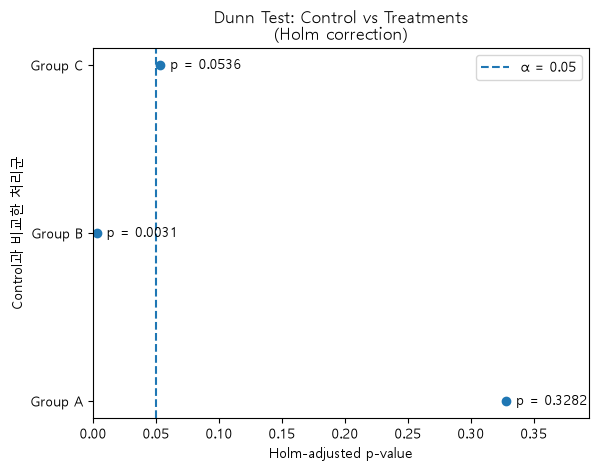

In [36]:
# Control과 각 처리군의 p-value만 추출
control_result = result.loc[
    "Control",
    ["Group A", "Group B", "Group C"]
]

print(control_result)

# 시각화
labels = control_result.index.astype(str)
p_values = control_result.values.astype(float)

y = np.arange(len(labels))

plt.scatter(p_values, y)

# 유의수준 기준선
plt.axvline(
    0.05,
    linestyle="--",
    label="α = 0.05"
)

# p-value 표시
for x, yy in zip(p_values, y):
    plt.text(
        x,
        yy,
        f"  p = {x:.4f}",
        va="center"
    )

plt.yticks(y, labels)

plt.xlim(
    0,
    max(0.1, p_values.max() * 1.2)
)

plt.xlabel("Holm-adjusted p-value")
plt.ylabel("Control과 비교한 처리군")

plt.title(
    "Dunn Test: Control vs Treatments\n"
    "(Holm correction)"
)

plt.legend()
plt.show()

해석:

- p < 0.05
→ 해당 처리군은 Control과 유의한 차이가 있음
- p >= 0.05
→ 해당 처리군은 Control과 유의한 차이가 있다고 보기 어려움

시각화에서도 점이 0.05 기준선 왼쪽에 있으면 유의, 오른쪽이면 유의하지 않다고 바로 확인할 수 있습니다.

scikit-posthocs의 현재 Steel 구현은 각 처리군과 대조군을 Mann-Whitney U 방식으로 비교하는 정규근사형 Steel 검정이며, 필요하면 여러 비교에 대한 p-value 보정을 함께 적용할 수 있습니다.

## 전체 요약 정리

| 분석 목적                     | 모수검정                        | 비모수검정                             |
| ------------------------- | --------------------------- | --------------------------------- |
| 독립된 **2집단** 비교            | 일반 t검정 / Welch t검정          | Mann–Whitney U, Wilcoxon Rank Sum |
| 2집단인데 **분산·분포 형태가 크게 다름** | 주로 Welch t                  | Fligner–Policello, Brunner–Munzel |
| 독립된 **3집단 이상 전체 비교**      | One-way ANOVA / Welch ANOVA | Kruskal–Wallis                    |
| 3집단 이상에서 **모든 쌍 비교**      | Tukey HSD / Games–Howell    | Steel–Dwass(DSCF), Dunn           |
| **1개 대조군 vs 여러 실험군**      | Dunnett                     | Steel                             |
| 집단 순서에 따라 **단조 증가·감소** 확인 | Linear trend contrast / 회귀  | Jonckheere–Terpstra               |
| 대응된 **2조건** 비교            | Paired t-test               | Wilcoxon signed-rank              |
| 대응된 **3조건 이상**            | Repeated-measures ANOVA     | Friedman test                     |


#### 정규성

| 방법           | 무엇을 보는가                | 판단                     |
| ------------ | ---------------------- | ---------------------- |
| Q-Q Plot     | 실제 데이터 분위수 vs 정규분포 분위수 | 점이 직선에 가까우면 정규성에 가까움   |
| Shapiro-Wilk | 정규분포와 유의하게 다른지         | p ≥ .05 → 정규성 위반 근거 부족 |
| K-S          | 경험적 분포와 특정 이론분포 비교     | 평균·SD를 데이터에서 추정하면 주의   |


#### 등분산성

| 방법             | 특징                | 추천 상황            |
| -------------- | ----------------- | ---------------- |
| Bartlett       | 정규성에 민감           | 데이터가 정규분포에 가까울 때 |
| Levene         | 정규성·이상치에 상대적으로 강함 | 일반적으로 더 무난       |
| Brown-Forsythe | 중앙값 기준 Levene 계열  | 비정규·이상치가 있을 때    |


#### 검정 목적별 방법

| 질문                       | 추천 방법                              |
| ------------------------ | ---------------------------------- |
| 두 독립집단 평균 비교, 등분산        | Student t                          |
| 두 독립집단 평균 비교, 이분산        | Welch t                            |
| 두 독립집단, 비정규              | Mann–Whitney U                     |
| 두 독립집단, 비정규 + 이분산        | Brunner–Munzel                     |
| 두 집단, 이분산이면서 대칭적 분포      | Fligner–Policello                  |
| 3집단 이상 평균 전체 비교          | One-way ANOVA                      |
| 3집단 이상 평균 비교 + 이분산       | Welch ANOVA                        |
| 3집단 이상 비모수 전체 비교         | Kruskal–Wallis                     |
| 모든 집단을 서로 비교, 모수         | Tukey / Games–Howell               |
| 모든 집단을 서로 비교, 비모수        | Steel–Dwass / DSCF / Dunn          |
| 하나의 Control과 여러 처리군, 모수  | Dunnett                            |
| 하나의 Control과 여러 처리군, 비모수 | Steel                              |
| 순서 있는 집단의 증가·감소, 모수      | Linear trend contrast / regression |
| 순서 있는 집단의 증가·감소, 비모수     | Jonckheere–Terpstra                |
